# HistGradientBoosting Baseline (v2)

This notebook trains `HistGradientBoostingRegressor` models for predicting:

- `target_next_URA`
- `target_next_IRI`

Changes from v1:
- Added `current_lag_static` feature set: lag features + static road attributes, without lifecycle features.
  This isolates whether static features help independently of lifecycle context.
- Added cells for 1-, 2-, 3- and 4-year horizon prediction.

The structure mirrors the earlier baseline notebooks so the results stay comparable.


In [12]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
plt.style.use("seaborn-v0_8-whitegrid")

DATA_PATH = Path("data/road_model_dataset_v1.parquet")
TRAIN_DATE_QUANTILE = 0.8
TRAIN_SAMPLE_N = 250_000
TEST_SAMPLE_N = 100_000
RANDOM_STATE = 42


In [13]:
cols = [
    "event_date",
    "URA",
    "IRI",
    "prev_URA",
    "prev_IRI",
    "Delta_t_years",
    "Pavement_Age_years",
    "Initial_URA",
    "Measurement_Idx",
    "Minor_TP_Count",
    "tp_count_interval",
    "has_TP_interval",
    "KVL",
    "KVL_raskas",
    "KVL_kaista",
    "Nopeus",
    "Toim_lk",
    "target_next_URA",
    "target_next_IRI",
    "target_horizon_days",
    "baseline_persist_URA",
    "baseline_persist_IRI",
]

df = pd.read_parquet(DATA_PATH, columns=cols)
df["event_date"] = pd.to_datetime(df["event_date"], errors="coerce")

print(f"Rows: {len(df):,}")
print(f"Date range: {df['event_date'].min().date()} -> {df['event_date'].max().date()}")
df.head()


Rows: 3,833,323
Date range: 2005-05-19 -> 2023-09-06


,event_date,URA,IRI,prev_URA,prev_IRI,Delta_t_years,Pavement_Age_years,Initial_URA,Measurement_Idx,Minor_TP_Count,tp_count_interval,has_TP_interval,KVL,KVL_raskas,KVL_kaista,Nopeus,Toim_lk,target_next_URA,target_next_IRI,target_horizon_days,baseline_persist_URA,baseline_persist_IRI
0,2018-06-18,2.7,1.60,NaN,NaN,NaN,0.0,2.7,1,1,1,True,182.0,23.0,80.0,80,yhdys,2.7,1.93,1527.0,2.7,1.60
1,2018-06-18,1.4,1.50,NaN,NaN,NaN,0.0,1.4,1,1,1,True,182.0,23.0,80.0,80,yhdys,1.7,1.70,1527.0,1.4,1.50
2,2018-06-18,1.5,1.75,NaN,NaN,NaN,0.0,1.5,1,1,1,True,182.0,23.0,80.0,80,yhdys,1.5,1.91,1527.0,1.5,1.75
3,2018-06-18,4.7,1.45,NaN,NaN,NaN,0.0,4.7,1,1,1,True,182.0,23.0,80.0,80,yhdys,3.5,1.66,1527.0,4.7,1.45
4,2018-06-18,1.4,2.42,NaN,NaN,NaN,0.0,1.4,1,1,1,True,182.0,23.0,80.0,80,yhdys,2.0,2.96,1527.0,1.4,2.42


### Next measurement prediction
Run ONLY this (ignore the next cell) if you want to predict the next measurement.

In [3]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train rows: {len(train_df):,}")
print(f"Test rows: {len(test_df):,}")
print(f"Train date range: {train_df['event_date'].min().date()} -> {train_df['event_date'].max().date()}")
print(f"Test date range: {test_df['event_date'].min().date()} -> {test_df['event_date'].max().date()}")


Cutoff date: 2020-08-18
Train rows: 3,096,068
Test rows: 737,255
Train date range: 2005-05-19 -> 2020-08-17
Test date range: 2020-08-18 -> 2023-09-06


### 1-year horizon prediction

In [14]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df = df.loc[df["event_date"] < cutoff_date].copy()
test_df = df.loc[df["event_date"] >= cutoff_date].copy()

# Filter to 1-year horizon
train_df = train_df[train_df["target_horizon_days"].between(274, 457)].copy()
test_df = test_df[test_df["target_horizon_days"].between(274, 457)].copy()

print(f"1-year horizon train rows: {len(train_df):,}")
print(f"1-year horizon test rows: {len(test_df):,}")

print(f"Cutoff date: {cutoff_date.date()}")
print(f"Train date range: {train_df['event_date'].min().date()} -> {train_df['event_date'].max().date()}")
print(f"Test date range: {test_df['event_date'].min().date()} -> {test_df['event_date'].max().date()}")

1-year horizon train rows: 1,434,070
1-year horizon test rows: 394,688
Cutoff date: 2020-08-18
Train date range: 2010-04-09 -> 2020-08-17
Test date range: 2020-08-18 -> 2023-09-03


In [15]:
def sample_rows(frame: pd.DataFrame, n: int, random_state: int) -> pd.DataFrame:
    if len(frame) <= n:
        return frame.copy()
    return frame.sample(n=n, random_state=random_state).copy()


train_sample = sample_rows(train_df, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample = sample_rows(test_df, TEST_SAMPLE_N, RANDOM_STATE)

print(f"Train sample rows: {len(train_sample):,}")
print(f"Test sample rows: {len(test_sample):,}")


Train sample rows: 250,000
Test sample rows: 100,000


In [17]:
def regression_metrics(y_true, y_pred, model_name, target_name):
    return {
        "model": model_name,
        "target": target_name,
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": mean_squared_error(y_true, y_pred) ** 0.5,
        "r2": r2_score(y_true, y_pred),
    }


def split_valid_feature_groups(frame: pd.DataFrame, selected_features):
    available = [c for c in selected_features if c in frame.columns]
    non_empty = [c for c in available if frame[c].notna().any()]
    dropped_all_missing = [c for c in available if c not in non_empty]
    numeric_features = [c for c in non_empty if c != "Toim_lk"]
    categorical_features = [c for c in ["Toim_lk"] if c in non_empty]
    return {
        "available": available,
        "non_empty": non_empty,
        "dropped_all_missing": dropped_all_missing,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
    }


def build_preprocessor(feature_groups):
    transformers = []

    if feature_groups["numeric_features"]:
        transformers.append(
            (
                "num",
                Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]),
                feature_groups["numeric_features"],
            )
        )

    if feature_groups["categorical_features"]:
        try:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
        except TypeError:
            one_hot = OneHotEncoder(handle_unknown="ignore", sparse=False)

        transformers.append(
            (
                "cat",
                Pipeline(
                    steps=[
                        ("imputer", SimpleImputer(strategy="most_frequent")),
                        ("onehot", one_hot),
                    ]
                ),
                feature_groups["categorical_features"],
            )
        )

    if not transformers:
        raise ValueError("No valid non-empty feature columns were found for preprocessing.")

    return ColumnTransformer(transformers=transformers)


feature_sets = {
    "current_only": [
        "URA",
        "IRI",
    ],
    "current_plus_lag": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
    ],
    "current_lag_static": [
        "URA", "IRI",
        "prev_URA", "prev_IRI", "Delta_t_years",
        "KVL", "KVL_raskas", "KVL_kaista", "Nopeus", "Toim_lk",
    ],
    "current_lag_lifecycle": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
        "Pavement_Age_years",
        "Initial_URA",
        "Measurement_Idx",
        "Minor_TP_Count",
        "tp_count_interval",
        "has_TP_interval",
    ],
    "current_lag_lifecycle_static": [
        "URA",
        "IRI",
        "prev_URA",
        "prev_IRI",
        "Delta_t_years",
        "Pavement_Age_years",
        "Initial_URA",
        "Measurement_Idx",
        "Minor_TP_Count",
        "tp_count_interval",
        "has_TP_interval",
        "KVL",
        "KVL_raskas",
        "KVL_kaista",
        "Nopeus",
        "Toim_lk",
    ],
}


In [18]:
hgb_model = HistGradientBoostingRegressor(
    loss="squared_error",
    learning_rate=0.05,
    max_iter=300,
    max_leaf_nodes=31,
    min_samples_leaf=50,
    l2_regularization=0.0,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

ablation_results = []
ablation_predictions = {}
fitted_models = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== Feature set: {feature_set_name} ===")

    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample[target_name].notna()
        test_target = test_sample[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample.columns]
        X_train = train_sample.loc[train_target, active_features].copy()
        y_train = train_sample.loc[train_target, target_name]
        X_test = test_sample.loc[test_target, active_features].copy()
        y_test = test_sample.loc[test_target, target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        print(f"Target: {target_name}")
        print(f"Requested features: {active_features}")
        print(f"Dropped all-missing features: {feature_groups['dropped_all_missing']}")

        pipe = Pipeline(
            steps=[
                ("preprocess", preprocess),
                ("model", clone(hgb_model)),
            ]
        )

        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        metrics = regression_metrics(y_test, y_pred, "hist_gradient_boosting", target_name)
        metrics["feature_set"] = feature_set_name
        metrics["n_features_requested"] = len(active_features)
        metrics["n_features_used"] = len(feature_groups["non_empty"])
        ablation_results.append(metrics)
        ablation_predictions[(feature_set_name, target_name)] = (y_test, y_pred)
        fitted_models[(feature_set_name, target_name)] = pipe

ablation_results_df = pd.DataFrame(ablation_results).sort_values(
    ["target", "rmse", "mae"]
).reset_index(drop=True)
ablation_results_df



=== Feature set: current_only ===
Target: target_next_URA
Requested features: ['URA', 'IRI']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI']
Dropped all-missing features: []

=== Feature set: current_plus_lag ===
Target: target_next_URA
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years']
Dropped all-missing features: []

=== Feature set: current_lag_static ===
Target: target_next_URA
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years', 'KVL', 'KVL_raskas', 'KVL_kaista', 'Nopeus', 'Toim_lk']
Dropped all-missing features: []
Target: target_next_IRI
Requested features: ['URA', 'IRI', 'prev_URA', 'prev_IRI', 'Delta_t_years', 'KVL', 'KVL_raskas', 'KVL_kaista', 'Nopeus', 'Toim_lk']
Dropped all-missing features: []

=== Feature set: current_lag_lifecycle ===
Target: targe

,model,target,mae,rmse,r2,feature_set,n_features_requested,n_features_used
0,hist_gradient_boosting,target_next_IRI,0.140084,0.281197,0.801995,current_lag_lifecycle_static,16,16
1,hist_gradient_boosting,target_next_IRI,0.140331,0.281855,0.801068,current_lag_static,10,10
2,hist_gradient_boosting,target_next_IRI,0.140524,0.281924,0.800970,current_lag_lifecycle,11,11
3,hist_gradient_boosting,target_next_IRI,0.140908,0.282655,0.799937,current_plus_lag,5,5
4,hist_gradient_boosting,target_next_IRI,0.145780,0.294559,0.782730,current_only,2,2
5,hist_gradient_boosting,target_next_URA,1.022667,1.473132,0.886040,current_lag_lifecycle_static,16,16
6,hist_gradient_boosting,target_next_URA,1.025666,1.476278,0.885553,current_lag_static,10,10
7,hist_gradient_boosting,target_next_URA,1.083740,1.544225,0.874776,current_lag_lifecycle,11,11
8,hist_gradient_boosting,target_next_URA,1.123814,1.593012,0.866738,current_plus_lag,5,5
9,hist_gradient_boosting,target_next_URA,1.174090,1.668304,0.853844,current_only,2,2


In [19]:
baseline_results = []

baseline_results.append(
    regression_metrics(
        test_sample["target_next_URA"],
        test_sample["baseline_persist_URA"],
        "persistence",
        "target_next_URA",
    )
)

baseline_results.append(
    regression_metrics(
        test_sample["target_next_IRI"],
        test_sample["baseline_persist_IRI"],
        "persistence",
        "target_next_IRI",
    )
)

baseline_results_df = pd.DataFrame(baseline_results)
baseline_results_df


,model,target,mae,rmse,r2
0,persistence,target_next_URA,1.890712,2.407464,0.695640
1,persistence,target_next_IRI,0.147781,0.305405,0.766435


In [20]:
best_hgb = (
    ablation_results_df.sort_values(["target", "rmse", "mae"])
    .groupby("target", as_index=False)
    .first()
)

comparison_df = pd.concat([
    baseline_results_df,
    best_hgb[["model", "target", "mae", "rmse", "r2"]],
], ignore_index=True).sort_values(["target", "rmse"])

comparison_df


,model,target,mae,rmse,r2
2,hist_gradient_boosting,target_next_IRI,0.140084,0.281197,0.801995
1,persistence,target_next_IRI,0.147781,0.305405,0.766435
3,hist_gradient_boosting,target_next_URA,1.022667,1.473132,0.886040
0,persistence,target_next_URA,1.890712,2.407464,0.695640


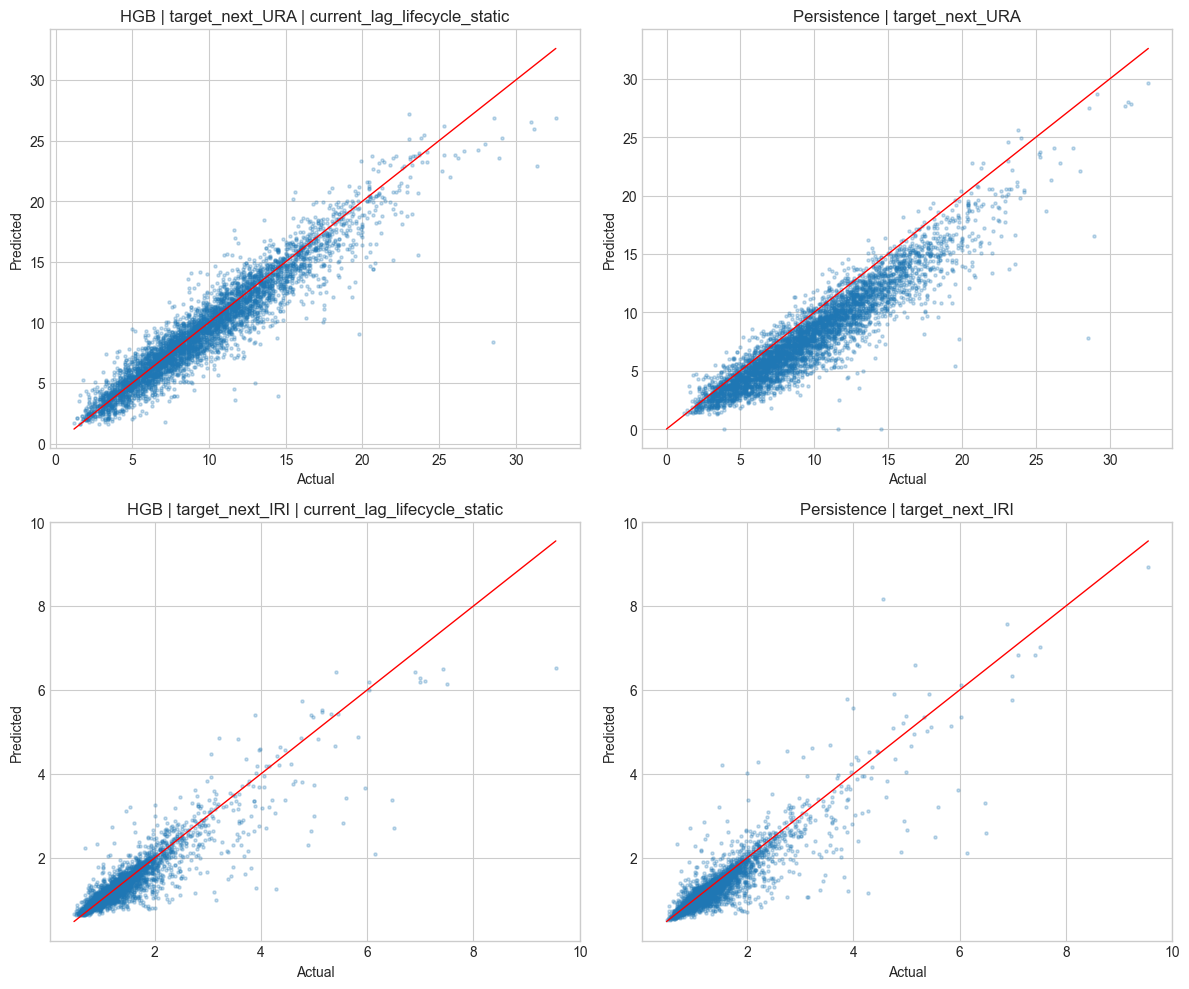

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
plot_targets = ["target_next_URA", "target_next_IRI"]

for row_idx, target_name in enumerate(plot_targets):
    best_row = best_hgb.loc[best_hgb["target"] == target_name].iloc[0]
    feature_set_name = best_row["feature_set"]
    y_true, y_pred = ablation_predictions[(feature_set_name, target_name)]

    plot_df = pd.DataFrame({"actual": y_true, "predicted": y_pred}).sample(
        n=min(5000, len(y_true)),
        random_state=RANDOM_STATE,
    )

    ax = axes[row_idx, 0]
    ax.scatter(plot_df["actual"], plot_df["predicted"], s=5, alpha=0.25)
    lo = min(plot_df["actual"].min(), plot_df["predicted"].min())
    hi = max(plot_df["actual"].max(), plot_df["predicted"].max())
    ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
    ax.set_title(f"HGB | {target_name} | {feature_set_name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

    baseline_col = "baseline_persist_URA" if target_name == "target_next_URA" else "baseline_persist_IRI"
    baseline_actual = test_sample[target_name]
    baseline_pred = test_sample[baseline_col]

    base_plot_df = pd.DataFrame({"actual": baseline_actual, "predicted": baseline_pred}).sample(
        n=min(5000, len(baseline_actual)),
        random_state=RANDOM_STATE,
    )

    ax = axes[row_idx, 1]
    ax.scatter(base_plot_df["actual"], base_plot_df["predicted"], s=5, alpha=0.25)
    lo = min(base_plot_df["actual"].min(), base_plot_df["predicted"].min())
    hi = max(base_plot_df["actual"].max(), base_plot_df["predicted"].max())
    ax.plot([lo, hi], [lo, hi], color="red", linewidth=1)
    ax.set_title(f"Persistence | {target_name}")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()


## How to use this notebook

If training is too slow, reduce:

- `TRAIN_SAMPLE_N`
- `TEST_SAMPLE_N`
- `max_iter`

If you want a stronger model, try tuning:

- `learning_rate`
- `max_leaf_nodes`
- `min_samples_leaf`
- `max_iter`

A good next step after this notebook would be a small hyperparameter search for the best feature set.


### 2-year horizon prediction

In [22]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_2yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_2yr = df.loc[df["event_date"] >= cutoff_date].copy()

train_df_2yr = train_df_2yr[train_df_2yr["target_horizon_days"].between(639, 822)].copy()
test_df_2yr = test_df_2yr[test_df_2yr["target_horizon_days"].between(639, 822)].copy()

print(f"2-year horizon train rows: {len(train_df_2yr):,}")
print(f"2-year horizon test rows:  {len(test_df_2yr):,}")
print(f"Mean horizon days: {train_df_2yr['target_horizon_days'].mean():.1f}")


2-year horizon train rows: 300,241
2-year horizon test rows:  133,130
Mean horizon days: 728.3


In [23]:
train_sample_2yr = sample_rows(train_df_2yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_2yr  = sample_rows(test_df_2yr,  TEST_SAMPLE_N,  RANDOM_STATE)
print(f"Train sample: {len(train_sample_2yr):,}  Test sample: {len(test_sample_2yr):,}")


Train sample: 250,000  Test sample: 100,000


In [24]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model_2yr = HistGradientBoostingRegressor(
    loss="squared_error", learning_rate=0.05, max_iter=300,
    max_leaf_nodes=31, min_samples_leaf=50, l2_regularization=0.0,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

baseline_2yr = []
baseline_2yr.append(regression_metrics(test_sample_2yr["target_next_URA"], test_sample_2yr["baseline_persist_URA"], "persistence", "target_next_URA"))
baseline_2yr.append(regression_metrics(test_sample_2yr["target_next_IRI"], test_sample_2yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

ablation_2yr = []
ablation_preds_2yr = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== {feature_set_name} ===")
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_2yr[target_name].notna()
        test_target  = test_sample_2yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_2yr.columns]
        X_train = train_sample_2yr.loc[train_target, active_features].copy()
        y_train = train_sample_2yr.loc[train_target, target_name]
        X_test  = test_sample_2yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_2yr.loc[test_target,  target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        from sklearn.base import clone
        from sklearn.pipeline import Pipeline
        pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clone(hgb_model_2yr))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        m = regression_metrics(y_test, y_pred, "hist_gradient_boosting", target_name)
        m["feature_set"] = feature_set_name
        ablation_2yr.append(m)
        ablation_preds_2yr[(feature_set_name, target_name)] = (y_test, y_pred)

abl_df_2yr = pd.DataFrame(ablation_2yr).sort_values(["target", "rmse"]).reset_index(drop=True)
summary_hgb_2yr = abl_df_2yr.pivot_table(index=["feature_set", "model"], columns="target", values=["mae", "rmse", "r2"])

print("\n=== 2-year horizon — HGB results ===")
display(summary_hgb_2yr)

print("\n=== 2-year horizon — persistence ===")
display(pd.DataFrame(baseline_2yr))



=== current_only ===

=== current_plus_lag ===

=== current_lag_static ===

=== current_lag_lifecycle ===

=== current_lag_lifecycle_static ===

=== 2-year horizon — HGB results ===


mae                              r2                            rmse                
target                                              target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                                 
current_lag_lifecycle        hist_gradient_boosting        0.222187        1.332766        0.833019        0.832444        0.365757        1.834914
current_lag_lifecycle_static hist_gradient_boosting        0.221407        1.230529        0.834607        0.849878        0.364014        1.736832
current_lag_static           hist_gradient_boosting        0.222537        1.234328        0.833498        0.847999        0.365232        1.747672
current_only                 hist_gradient_boosting        0.221390        1.335486        0.828197        0.831408        0.371001        1.840582
current_plus_lag             hist_gradient_boosting        0.222311        1.330377        0.833463        0.831634        0.365271        1.839348


=== 2-year horizon — persistence ===


,model,target,mae,rmse,r2
0,persistence,target_next_URA,2.381855,2.904338,0.580220
1,persistence,target_next_IRI,0.237709,0.400372,0.799917


### 3-year horizon prediction

In [25]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_3yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_3yr = df.loc[df["event_date"] >= cutoff_date].copy()

train_df_3yr = train_df_3yr[train_df_3yr["target_horizon_days"].between(1004, 1187)].copy()
test_df_3yr = test_df_3yr[test_df_3yr["target_horizon_days"].between(1004, 1187)].copy()

print(f"3-year horizon train rows: {len(train_df_3yr):,}")
print(f"3-year horizon test rows:  {len(test_df_3yr):,}")
print(f"Mean horizon days: {train_df_3yr['target_horizon_days'].mean():.1f}")


3-year horizon train rows: 663,314
3-year horizon test rows:  171,818
Mean horizon days: 1100.1


In [26]:
train_sample_3yr = sample_rows(train_df_3yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_3yr  = sample_rows(test_df_3yr,  TEST_SAMPLE_N,  RANDOM_STATE)
print(f"Train sample: {len(train_sample_3yr):,}  Test sample: {len(test_sample_3yr):,}")


Train sample: 250,000  Test sample: 100,000


In [27]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model_3yr = HistGradientBoostingRegressor(
    loss="squared_error", learning_rate=0.05, max_iter=300,
    max_leaf_nodes=31, min_samples_leaf=50, l2_regularization=0.0,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

baseline_3yr = []
baseline_3yr.append(regression_metrics(test_sample_3yr["target_next_URA"], test_sample_3yr["baseline_persist_URA"], "persistence", "target_next_URA"))
baseline_3yr.append(regression_metrics(test_sample_3yr["target_next_IRI"], test_sample_3yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

ablation_3yr = []
ablation_preds_3yr = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== {feature_set_name} ===")
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_3yr[target_name].notna()
        test_target  = test_sample_3yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_3yr.columns]
        X_train = train_sample_3yr.loc[train_target, active_features].copy()
        y_train = train_sample_3yr.loc[train_target, target_name]
        X_test  = test_sample_3yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_3yr.loc[test_target,  target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        from sklearn.base import clone
        from sklearn.pipeline import Pipeline
        pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clone(hgb_model_3yr))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        m = regression_metrics(y_test, y_pred, "hist_gradient_boosting", target_name)
        m["feature_set"] = feature_set_name
        ablation_3yr.append(m)
        ablation_preds_3yr[(feature_set_name, target_name)] = (y_test, y_pred)

abl_df_3yr = pd.DataFrame(ablation_3yr).sort_values(["target", "rmse"]).reset_index(drop=True)
summary_hgb_3yr = abl_df_3yr.pivot_table(index=["feature_set", "model"], columns="target", values=["mae", "rmse", "r2"])

print("\n=== 3-year horizon — HGB results ===")
display(summary_hgb_3yr)

print("\n=== 3-year horizon — persistence ===")
display(pd.DataFrame(baseline_3yr))



=== current_only ===

=== current_plus_lag ===

=== current_lag_static ===

=== current_lag_lifecycle ===

=== current_lag_lifecycle_static ===

=== 3-year horizon — HGB results ===


mae                              r2                            rmse                
target                                              target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                                 
current_lag_lifecycle        hist_gradient_boosting        0.319144        1.562275        0.840353        0.772680        0.506761        2.175360
current_lag_lifecycle_static hist_gradient_boosting        0.315486        1.546987        0.844484        0.768796        0.500162        2.193866
current_lag_static           hist_gradient_boosting        0.316702        1.589578        0.842647        0.755402        0.503108        2.256520
current_only                 hist_gradient_boosting        0.327018        1.582047        0.828902        0.759792        0.524622        2.236180
current_plus_lag             hist_gradient_boosting        0.321413        1.588785        0.837370        0.762045        0.511474        2.225669


=== 3-year horizon — persistence ===


,model,target,mae,rmse,r2
0,persistence,target_next_URA,2.445847,3.115647,0.533694
1,persistence,target_next_IRI,0.362851,0.568144,0.799336


### 4-year horizon prediction

In [28]:
unique_dates = np.sort(df["event_date"].dropna().unique())
cut_idx = int(len(unique_dates) * TRAIN_DATE_QUANTILE)
cut_idx = min(max(cut_idx, 1), len(unique_dates) - 1)
cutoff_date = pd.Timestamp(unique_dates[cut_idx])

train_df_4yr = df.loc[df["event_date"] < cutoff_date].copy()
test_df_4yr = df.loc[df["event_date"] >= cutoff_date].copy()

train_df_4yr = train_df_4yr[train_df_4yr["target_horizon_days"].between(1370, 1553)].copy()
test_df_4yr = test_df_4yr[test_df_4yr["target_horizon_days"].between(1370, 1553)].copy()

print(f"4-year horizon train rows: {len(train_df_4yr):,}")
print(f"4-year horizon test rows:  {len(test_df_4yr):,}")
print(f"Mean horizon days: {train_df_4yr['target_horizon_days'].mean():.1f}")


4-year horizon train rows: 352,563
4-year horizon test rows:  1,486
Mean horizon days: 1465.4


In [29]:
train_sample_4yr = sample_rows(train_df_4yr, TRAIN_SAMPLE_N, RANDOM_STATE)
test_sample_4yr  = sample_rows(test_df_4yr,  TEST_SAMPLE_N,  RANDOM_STATE)
print(f"Train sample: {len(train_sample_4yr):,}  Test sample: {len(test_sample_4yr):,}")


Train sample: 250,000  Test sample: 1,486


In [30]:
from sklearn.ensemble import HistGradientBoostingRegressor

hgb_model_4yr = HistGradientBoostingRegressor(
    loss="squared_error", learning_rate=0.05, max_iter=300,
    max_leaf_nodes=31, min_samples_leaf=50, l2_regularization=0.0,
    early_stopping=True, validation_fraction=0.1, n_iter_no_change=20,
    random_state=RANDOM_STATE,
)

baseline_4yr = []
baseline_4yr.append(regression_metrics(test_sample_4yr["target_next_URA"], test_sample_4yr["baseline_persist_URA"], "persistence", "target_next_URA"))
baseline_4yr.append(regression_metrics(test_sample_4yr["target_next_IRI"], test_sample_4yr["baseline_persist_IRI"], "persistence", "target_next_IRI"))

ablation_4yr = []
ablation_preds_4yr = {}

for feature_set_name, selected_features in feature_sets.items():
    print(f"\n=== {feature_set_name} ===")
    for target_name in ["target_next_URA", "target_next_IRI"]:
        train_target = train_sample_4yr[target_name].notna()
        test_target  = test_sample_4yr[target_name].notna()

        active_features = [c for c in selected_features if c in train_sample_4yr.columns]
        X_train = train_sample_4yr.loc[train_target, active_features].copy()
        y_train = train_sample_4yr.loc[train_target, target_name]
        X_test  = test_sample_4yr.loc[test_target,  active_features].copy()
        y_test  = test_sample_4yr.loc[test_target,  target_name]

        feature_groups = split_valid_feature_groups(X_train, active_features)
        preprocess = build_preprocessor(feature_groups)

        from sklearn.base import clone
        from sklearn.pipeline import Pipeline
        pipe = Pipeline(steps=[("preprocess", preprocess), ("model", clone(hgb_model_4yr))])
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)

        m = regression_metrics(y_test, y_pred, "hist_gradient_boosting", target_name)
        m["feature_set"] = feature_set_name
        ablation_4yr.append(m)
        ablation_preds_4yr[(feature_set_name, target_name)] = (y_test, y_pred)

abl_df_4yr = pd.DataFrame(ablation_4yr).sort_values(["target", "rmse"]).reset_index(drop=True)
summary_hgb_4yr = abl_df_4yr.pivot_table(index=["feature_set", "model"], columns="target", values=["mae", "rmse", "r2"])

print("\n=== 4-year horizon — HGB results ===")
display(summary_hgb_4yr)

print("\n=== 4-year horizon — persistence ===")
display(pd.DataFrame(baseline_4yr))



=== current_only ===

=== current_plus_lag ===

=== current_lag_static ===

=== current_lag_lifecycle ===

=== current_lag_lifecycle_static ===

=== 4-year horizon — HGB results ===


mae                              r2                            rmse                
target                                              target_next_IRI target_next_URA target_next_IRI target_next_URA target_next_IRI target_next_URA
feature_set                  model                                                                                                                 
current_lag_lifecycle        hist_gradient_boosting        0.469264        1.989765        0.787984        0.751458        0.682264        2.795810
current_lag_lifecycle_static hist_gradient_boosting        0.481490        2.019131        0.780424        0.739781        0.694322        2.860733
current_lag_static           hist_gradient_boosting        0.479375        2.024817        0.782484        0.735745        0.691058        2.882836
current_only                 hist_gradient_boosting        0.503342        2.069070        0.739929        0.708701        0.755639        3.026758
current_plus_lag             hist_gradient_boosting        0.467445        2.015212        0.788452        0.742193        0.681512        2.847444


=== 4-year horizon — persistence ===


,model,target,mae,rmse,r2
0,persistence,target_next_URA,3.480417,4.383473,0.389029
1,persistence,target_next_IRI,0.527961,0.810099,0.701091
